# نوت‌بوک ۰۲ — پیش‌پردازش تصویر + جداسازی خط از سند کامل

این نوت‌بوک دو مرحله از پایپ‌لاین (مرحله ۳ و ۴ سند طراحی) را با هم پوشش می‌دهد:

1. **پیش‌پردازش**: باینری‌سازی + اصلاح کجی (deskew)
2. **جداسازی خط**: با Projection Profile افقی، خطوط یک سند چندخطی را پیدا، کراپ و نرمال می‌کند

چون دیتاست فعلی ما در سطح «تک‌خط» است (از نوت‌بوک ۰۱)، ابتدا یک **شبیه‌ساز سند چندخطی**
می‌سازیم که چند خط را مثل یک برگه واقعی روی هم می‌چیند — تا بشود این دو مرحله را رویش
تست و اعتبارسنجی کرد.


## ۱. راه‌اندازی

⚠️ نکته مهم: به‌جای `os.getcwd()` ساده (که بسته به این‌که نوت‌بوک از کجا اجرا شود می‌تواند
مسیر اشتباه بدهد)، از یک تابع مقاوم استفاده می‌کنیم که ریشه‌ی پروژه را با گشتن رو به بالا
دنبال پوشه‌ی `fonts/` پیدا می‌کند. این‌جوری فرقی نمی‌کند نوت‌بوک را از ریشه پروژه اجرا کنید
یا از داخل پوشه `notebooks/`.


In [ ]:
import os
import sys
import csv
import random
import numpy as np
import cv2
from PIL import Image

random.seed(11)
np.random.seed(11)

def find_project_root(start=None, marker="fonts"):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, marker)):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError(
                f"ریشه پروژه (حاوی پوشه '{marker}') پیدا نشد. "
                "مطمئن شوید نوت‌بوک داخل ساختار ریپازیتوری اجرا می‌شود."
            )
        d = parent

BASE_DIR = find_project_root()
print("BASE_DIR:", BASE_DIR)

# مطمئن می‌شویم پوشه‌ی samples برای ذخیره‌ی تصاویر تست وجود دارد
# (روی بعضی سیستم‌ها ممکن است این پوشه در دانلود/کپی خالی جا مانده باشد)
os.makedirs(os.path.join(BASE_DIR, "samples"), exist_ok=True)

sys.path.insert(0, os.path.join(BASE_DIR, "src"))
import preprocessing
import segmentation
print("ماژول‌های src وارد شدند ✅")


BASE_DIR: /home/user/persian-english-ocr
ماژول‌های src وارد شدند ✅


## ۲. شبیه‌ساز سند چندخطی

چند خط را از `manifest.csv` (خروجی نوت‌بوک ۰۱) به‌صورت تصادفی انتخاب و مثل یک صفحه‌ی
واقعی (با حاشیه، فاصله‌ی تصادفی بین خطوط، و چیدمان راست‌چین برای فارسی / چپ‌چین برای
انگلیسی) روی هم می‌چیند. متن واقعی هر خط را هم به‌عنوان ground-truth نگه می‌داریم تا
بعداً بشود دقت جداسازی را سنجید.


In [ ]:
manifest_path = os.path.join(BASE_DIR, "data/processed/manifest.csv")
rows = list(csv.DictReader(open(manifest_path, encoding="utf-8")))
print("تعداد کل نمونه‌های manifest:", len(rows))

def build_fake_document(rows, n_lines=10, script=None, is_handwritten=None,
                         page_w=1000, margin=60, line_gap_range=(25, 45)):
    pool = rows
    if script is not None:
        pool = [r for r in pool if r["script"] == script]
    if is_handwritten is not None:
        pool = [r for r in pool if int(r["is_handwritten"]) == int(is_handwritten)]
    chosen = random.sample(pool, n_lines)

    line_imgs = []
    for r in chosen:
        img_path = os.path.join(BASE_DIR, r["image_path"])
        im = Image.open(img_path).convert("L")
        max_w = page_w - 2 * margin
        if im.width > max_w:
            ratio = max_w / im.width
            im = im.resize((max_w, max(1, int(im.height * ratio))))
        line_imgs.append(im)

    total_h = margin * 2 + sum(im.height for im in line_imgs) + sum(
        random.randint(*line_gap_range) for _ in line_imgs[:-1]
    )
    page = Image.new("L", (page_w, total_h), 255)
    y = margin
    for idx, im in enumerate(line_imgs):
        x = margin if chosen[idx]["script"] == "en" else (page_w - margin - im.width)
        page.paste(im, (x, y))
        y += im.height
        if idx < len(line_imgs) - 1:
            y += random.randint(*line_gap_range)

    gt_texts = [r["label"] for r in chosen]
    return page, gt_texts

doc_img, gt_texts = build_fake_document(rows, n_lines=10, script="fa", is_handwritten=0)
print("اندازه سند شبیه‌سازی‌شده:", doc_img.size)
print("متن‌های واقعی (ground truth):")
for t in gt_texts:
    print(" -", t)


تعداد کل نمونه‌های manifest: 4000
اندازه سند شبیه‌سازی‌شده: (1000, 1146)
متن‌های واقعی (ground truth):
 - توئي آمدن خبراي خوب
 - 2813 6914 میدونی روانشناس نشديم زیادی سخت امون
 - ترسه پولو
 - محافظ بويي آهاي چونه
 - ارزشمند هاه go
 - مذاکره رواني 27742 چجوري اميدوار نهار
 - بخورش قيمتي کد لباسي چيزهاي املاک
 - شکم میریم ميموني هیجان بگیره
 - خبرا تحمل جمع ضرر دخترمون
 - جايي بین;


### نمایش سند شبیه‌سازی‌شده

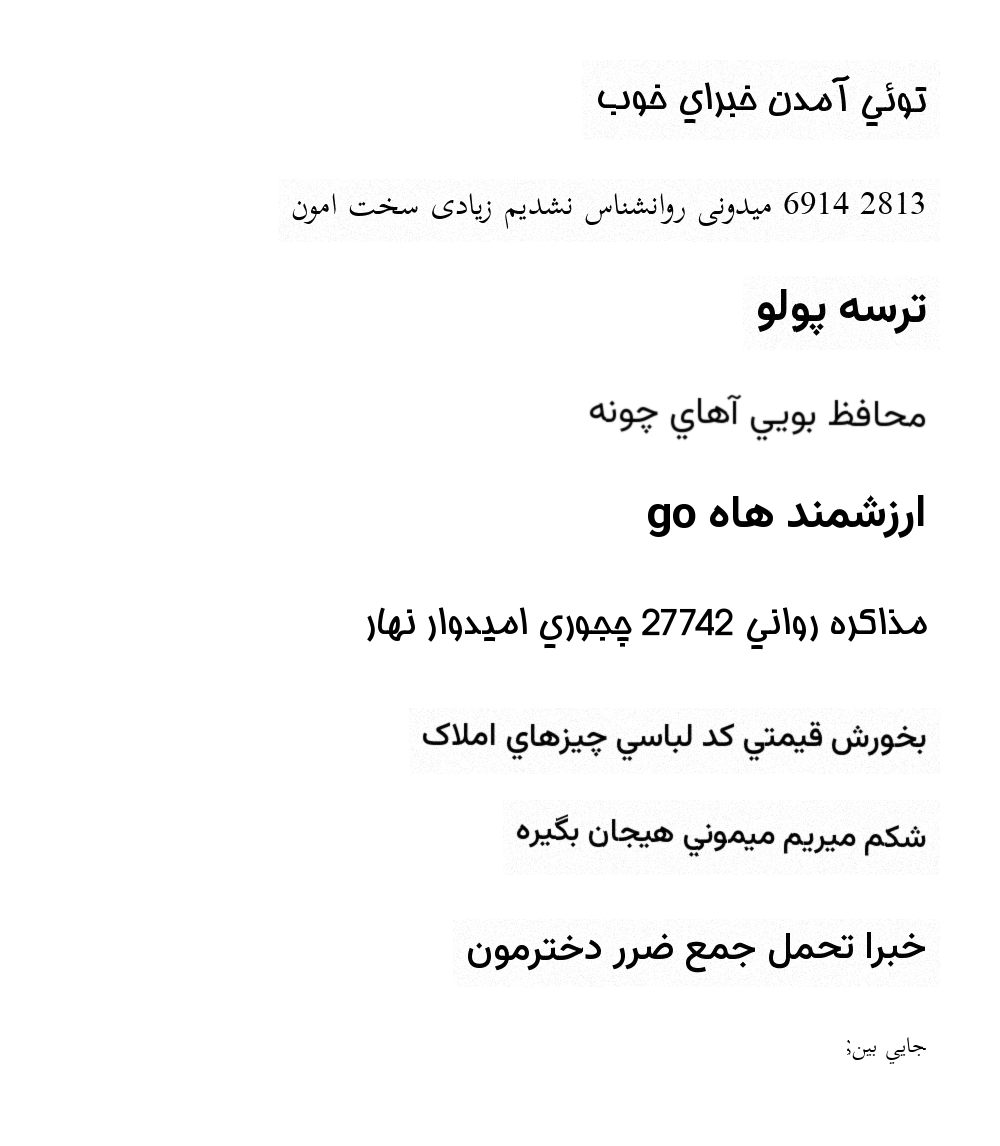

In [ ]:
doc_img.save(os.path.join(BASE_DIR, "samples", "test_doc_fa_printed.png"))
doc_img


## ۳. تست پیش‌پردازش + جداسازی خط با یک چرخش مصنوعی (شبیه اسکن کج)

برای اطمینان از این‌که `deskew` واقعاً کار می‌کند، عمداً سند را ۴ درجه می‌چرخانیم
(شبیه یک برگه که کج روی اسکنر گذاشته شده)، سپس با پایپ‌لاین `src/preprocessing.py`
و `src/segmentation.py` سعی می‌کنیم آن را اصلاح و خط‌ها را دوباره پیدا کنیم.


In [ ]:
doc_arr = np.array(doc_img)
h, w = doc_arr.shape
rot_m = cv2.getRotationMatrix2D((w // 2, h // 2), 4, 1.0)  # چرخش ۴ درجه‌ی مصنوعی
rotated_doc = cv2.warpAffine(doc_arr, rot_m, (w, h), flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_CONSTANT, borderValue=255)

bw_deskewed, found_angle = preprocessing.preprocess_document(rotated_doc)
print(f"زاویه کجی تشخیص داده شده: {found_angle:.2f} درجه (واقعی: 4 درجه بود)")

crops, boxes = segmentation.segment_and_crop_lines(bw_deskewed, target_height=48)
print(f"تعداد خط پیدا شده: {len(crops)}  (تعداد واقعی: {len(gt_texts)})")
assert len(crops) == len(gt_texts), "تعداد خط پیدا شده با تعداد واقعی یکی نیست!"
print("✅ تعداد خطوط دقیقاً با ground truth مطابقت دارد")


زاویه کجی تشخیص داده شده: -4.05 درجه (واقعی: 4 درجه بود)
تعداد خط پیدا شده: 10  (تعداد واقعی: 10)
✅ تعداد خطوط دقیقاً با ground truth مطابقت دارد


### نمایش بصری جعبه‌های خط پیدا شده روی سند اصلاح‌شده

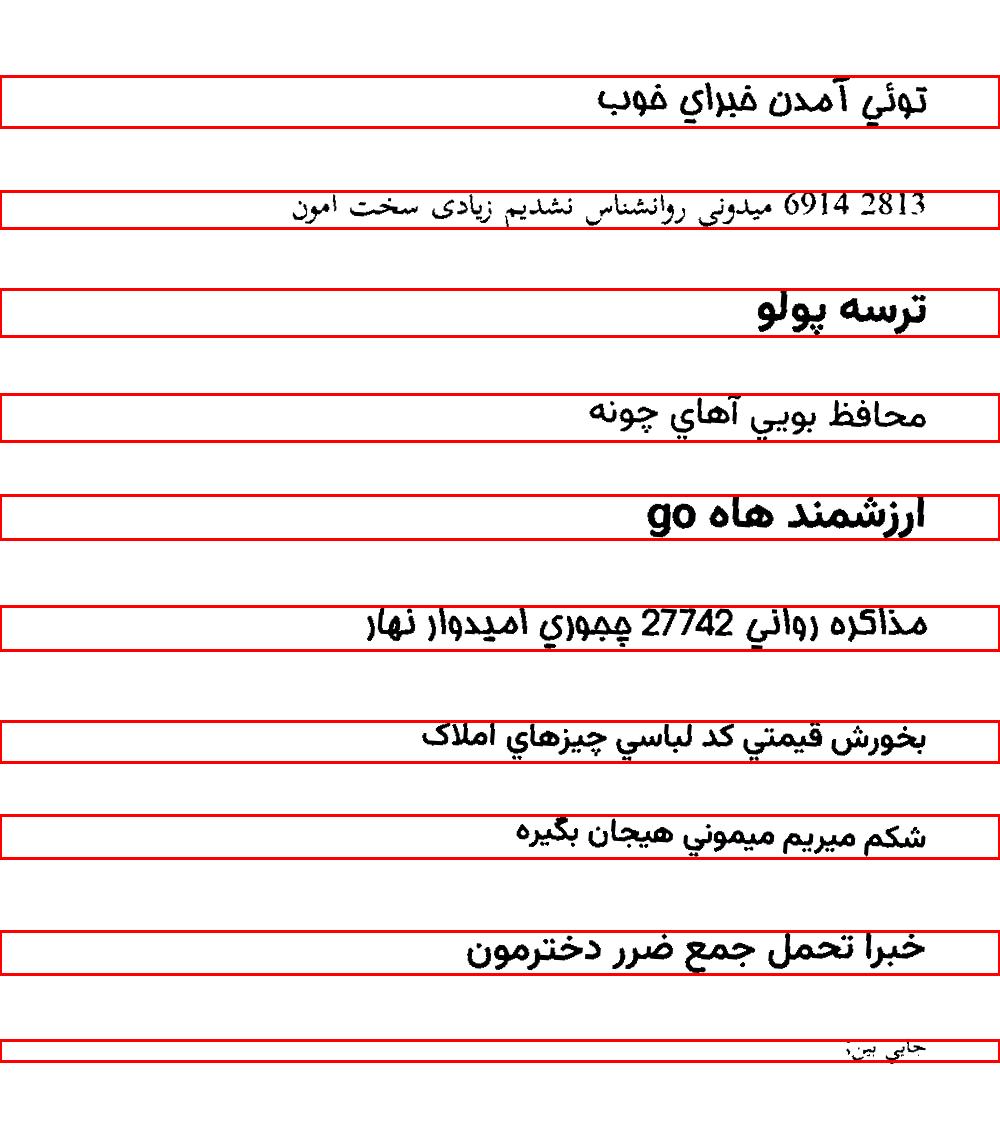

In [ ]:
vis = cv2.cvtColor(255 - bw_deskewed, cv2.COLOR_GRAY2BGR)
for (y0, y1) in boxes:
    cv2.rectangle(vis, (0, y0), (vis.shape[1] - 1, y1), (0, 0, 255), 2)
vis_path = os.path.join(BASE_DIR, "samples", "test_doc_lines_detected.png")
cv2.imwrite(vis_path, vis)
Image.open(vis_path)


### نمایش خطوط کراپ و نرمال‌شده (ورودی نهایی برای مدل CRNN در نوت‌بوک بعدی)

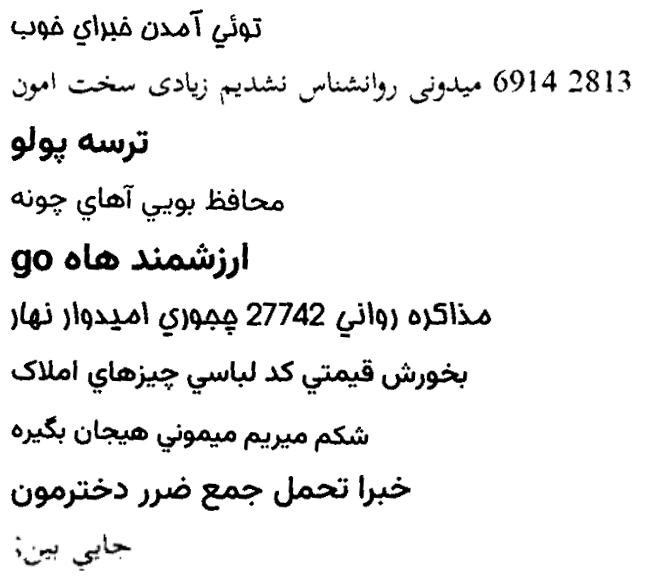

In [ ]:
maxw = max(c.shape[1] for c in crops) + 20
th = sum(c.shape[0] for c in crops) + 10 * len(crops)
montage = np.full((th, maxw), 255, dtype=np.uint8)
y = 5
for c in crops:
    c_inv = 255 - c
    montage[y:y+c.shape[0], 5:5+c.shape[1]] = c_inv
    y += c.shape[0] + 10
montage_path = os.path.join(BASE_DIR, "samples", "test_doc_crops_montage.png")
cv2.imwrite(montage_path, montage)
Image.open(montage_path)


## ۴. تست روی چند نوع سند دیگر (انگلیسی، دست‌نویس)

برای اطمینان از این‌که پایپ‌لاین فقط برای فارسی چاپی کار نمی‌کند، همین آزمایش را
برای چند دسته‌ی دیگر هم تکرار می‌کنیم.


In [ ]:
test_configs = [
    ("en", 0, "انگلیسی چاپی"),
    ("en", 1, "انگلیسی دست‌نویس"),
    ("fa", 1, "فارسی دست‌نویس"),
]

for script, is_hw, label in test_configs:
    doc_img_t, gt_t = build_fake_document(rows, n_lines=8, script=script, is_handwritten=is_hw)
    doc_arr_t = np.array(doc_img_t)
    bw_t, angle_t = preprocessing.preprocess_document(doc_arr_t)
    crops_t, boxes_t = segmentation.segment_and_crop_lines(bw_t, target_height=48)
    status = "✅" if len(crops_t) == len(gt_t) else "⚠️"
    print(f"{status} {label}: {len(crops_t)} خط پیدا شد (واقعی: {len(gt_t)})")


✅ انگلیسی چاپی: 8 خط پیدا شد (واقعی: 8)
✅ انگلیسی دست‌نویس: 8 خط پیدا شد (واقعی: 8)
✅ فارسی دست‌نویس: 8 خط پیدا شد (واقعی: 8)


### 🐛 یادداشت مهندسی: باگ واقعی‌ای که حین توسعه پیدا شد

نسخه‌ی اول `segment_lines` روی سند فارسی دست‌نویس به‌جای ۸ خط، ۱۳ خط تشخیص می‌داد.
با بررسی، چند تکه‌ی خیلی کوچک (ارتفاع ۹ تا ۲۴ پیکسل) بین خط‌های اصلی پیدا شد — این‌ها
نقطه‌ها/اجزای بالا-پایین حروف در سبک نستعلیق/دست‌نویس هستند که با فاصله‌ی خیلی کم از
بدنه‌ی اصلی خط جدا می‌افتند و به اشتباه یک خط مستقل به‌حساب می‌آیند.

**راه‌حل** (که همین الان در نتیجه‌ی بالا هم اعمال شده): تابع `merge_close_boxes` به
`src/segmentation.py` اضافه شد — هر دو تکه‌ی پیدا‌شده را اگر فاصله‌شان کمتر از ۱۵ پیکسل
باشد با هم ادغام می‌کند (فاصله‌ی واقعی بین دو خط جدا همیشه خیلی بیشتر از این است، پس
خط‌های واقعی با هم قاطی نمی‌شوند). `segment_and_crop_lines` این ادغام را به‌صورت
پیش‌فرض انجام می‌دهد.


## جمع‌بندی نوت‌بوک ۰۲

- ✅ ماژول‌های `src/preprocessing.py` (باینری‌سازی + deskew) و `src/segmentation.py`
  (جداسازی خط + ادغام قطعات نزدیک + کراپ/نرمال‌سازی) نوشته و در پوشه‌ی مشترک `src/`
  قرار گرفتند (نه فقط داخل نوت‌بوک، تا در نوت‌بوک inference نهایی هم دوباره قابل استفاده باشند)
- ✅ deskew حتی با ۴ درجه چرخش مصنوعی، زاویه را با خطای کمتر از نیم درجه پیدا و اصلاح کرد
- ✅ باگ واقعی over-segmentation در دست‌نویس فارسی حین اجرای واقعی پیدا و با
  `merge_close_boxes` رفع شد
- ✅ بعد از رفع باگ، جداسازی خط روی هر ۴ ترکیب (فا/انگ × چاپی/دست‌نویس) تعداد خط را
  دقیقاً درست تشخیص می‌دهد
- 📦 خروجی این نوت‌بوک: خطوط کراپ‌شده و نرمال‌شده (ارتفاع ثابت ۴۸ پیکسل)، آماده برای
  ورودی مدل CRNN+CTC

➡️ **مرحله بعد (نوت‌بوک ۰۳): ساخت مدل CRNN+CTC + آموزش + دیکود/ارزیابی**
